In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [2]:
# Load cleaned dataset
df = pd.read_csv("g2f_2023_phenotypic_model_ready.csv", encoding="latin1", low_memory=False)

print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (18888, 26)


,Year,Field-Location,State,City,Plot length (center-center in feet),Plot area (ft2),Alley length (in inches),Row spacing (in inches),Rows per plot,# Seed per plot,...,Silking [days],Plant Height [cm],Ear Height [cm],Stand Count [# of plants],Root Lodging [# of plants],Stalk Lodging [# of plants],Grain Moisture [%],Test Weight [lbs],Plot Weight [lbs],Grain Yield (bu/A)
0,2023,COH1,CO,Fort Collins,20.0,85.0,36,30,2,80,...,97.0,235.0,104.0,35.0,0.0,0.0,25.1,51.3,26.9,218.201789
1,2023,COH1,CO,Fort Collins,20.0,85.0,36,30,2,80,...,97.0,235.0,104.0,29.0,0.0,0.0,25.5,48.9,24.8,200.093123
2,2023,COH1,CO,Fort Collins,20.0,85.0,36,30,2,80,...,78.0,235.0,104.0,38.0,0.0,0.0,16.2,56.7,28.8,261.372996
3,2023,COH1,CO,Fort Collins,20.0,85.0,36,30,2,80,...,78.0,235.0,104.0,36.0,0.0,0.0,20.1,52.2,24.1,208.539358
4,2023,COH1,CO,Fort Collins,20.0,85.0,36,30,2,80,...,97.0,235.0,104.0,39.0,0.0,0.0,28.0,48.4,27.4,213.652151


In [3]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18888 entries, 0 to 18887
Data columns (total 26 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Year                                 18888 non-null  int64  
 1   Field-Location                       18888 non-null  object 
 2   State                                18888 non-null  object 
 3   City                                 18888 non-null  object 
 4   Plot length (center-center in feet)  18888 non-null  float64
 5   Plot area (ft2)                      18888 non-null  float64
 6   Alley length (in inches)             18888 non-null  int64  
 7   Row spacing (in inches)              18888 non-null  int64  
 8   Rows per plot                        18888 non-null  int64  
 9   # Seed per plot                      18888 non-null  int64  
 10  Experiment                           18888 non-null  object 
 11  Pedigree                    

In [4]:
# Check missing values
df.isna().sum().sort_values(ascending=False).head(20)


Year                                   0
Field-Location                         0
State                                  0
City                                   0
Plot length (center-center in feet)    0
Plot area (ft2)                        0
Alley length (in inches)               0
Row spacing (in inches)                0
Rows per plot                          0
# Seed per plot                        0
Experiment                             0
Pedigree                               0
Family                                 0
Replicate                              0
Block                                  0
Anthesis [days]                        0
Silking [days]                         0
Plant Height [cm]                      0
Ear Height [cm]                        0
Stand Count [# of plants]              0
dtype: int64

In [5]:
# Define target and features
TARGET = "Grain Yield (bu/A)"

X = df.drop(columns=[TARGET])
y = df[TARGET]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (18888, 25)
y shape: (18888,)


In [6]:
# Train / validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)


Training set: (15110, 25)
Validation set: (3778, 25)


In [7]:
# Identify numeric and categorical columns
numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

print("Number of numeric columns:", len(numeric_cols))
print("Number of categorical columns:", len(categorical_cols))
print("\nNumeric columns:")
print(numeric_cols)
print("\nCategorical columns:")
print(categorical_cols)


Number of numeric columns: 19
Number of categorical columns: 6

Numeric columns:
['Year', 'Plot length (center-center in feet)', 'Plot area (ft2)', 'Alley length (in inches)', 'Row spacing (in inches)', 'Rows per plot', '# Seed per plot', 'Replicate', 'Block', 'Anthesis [days]', 'Silking [days]', 'Plant Height [cm]', 'Ear Height [cm]', 'Stand Count [# of plants]', 'Root Lodging [# of plants]', 'Stalk Lodging [# of plants]', 'Grain Moisture [%]', 'Test Weight [lbs]', 'Plot Weight [lbs]']

Categorical columns:
['Field-Location', 'State', 'City', 'Experiment', 'Pedigree', 'Family']


In [8]:
# Preprocessing for Ridge
ridge_preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
])

# Preprocessing for Random Forest
rf_preprocessor = ColumnTransformer(transformers=[
    ("num", "passthrough", numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
])


In [9]:
# Ridge pipeline
ridge_pipeline = Pipeline(steps=[
    ("preprocessor", ridge_preprocessor),
    ("model", Ridge())
])

# Ridge hyperparameter grid
ridge_param_grid = {
    "model__alpha": [0.01, 0.1, 1.0, 10.0, 50.0, 100.0]
}

# Ridge GridSearch
ridge_grid = GridSearchCV(
    ridge_pipeline,
    ridge_param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

ridge_grid.fit(X_train, y_train)

print("Best Ridge parameters:", ridge_grid.best_params_)
print("Best Ridge CV RMSE:", -ridge_grid.best_score_)


Best Ridge parameters: {'model__alpha': 1.0}
Best Ridge CV RMSE: 5.717480618634327


In [10]:
# Best Ridge model predictions
ridge_best = ridge_grid.best_estimator_

ridge_train_pred = ridge_best.predict(X_train)
ridge_val_pred = ridge_best.predict(X_val)

# Ridge train metrics
ridge_train_rmse = np.sqrt(mean_squared_error(y_train, ridge_train_pred))
ridge_train_mae = mean_absolute_error(y_train, ridge_train_pred)
ridge_train_r2 = r2_score(y_train, ridge_train_pred)

# Ridge validation metrics
ridge_val_rmse = np.sqrt(mean_squared_error(y_val, ridge_val_pred))
ridge_val_mae = mean_absolute_error(y_val, ridge_val_pred)
ridge_val_r2 = r2_score(y_val, ridge_val_pred)

ridge_metrics_table = pd.DataFrame({
    "Dataset": ["Train", "Validation"],
    "RMSE": [ridge_train_rmse, ridge_val_rmse],
    "MAE": [ridge_train_mae, ridge_val_mae],
    "R2": [ridge_train_r2, ridge_val_r2]
})

print("Ridge results:")
display(ridge_metrics_table)


Ridge results:


,Dataset,RMSE,MAE,R2
0,Train,5.402608,3.522156,0.990539
1,Validation,5.653890,3.750153,0.989799


In [11]:
# Ridge validation predictions table
ridge_predictions_val = pd.DataFrame({
    "Actual": y_val.values,
    "Predicted": ridge_val_pred,
    "Residual": y_val.values - ridge_val_pred
})

ridge_predictions_val.head(10)


,Actual,Predicted,Residual
0,119.477265,115.945202,3.532063
1,178.350768,179.235643,-0.884875
2,203.443979,202.750475,0.693504
3,91.889574,68.311203,23.578371
4,125.504350,123.026298,2.478052
5,170.512100,172.076345,-1.564245
6,170.287738,167.683495,2.604243
7,187.510519,184.089711,3.420808
8,124.009628,131.384683,-7.375055
9,70.669391,79.107669,-8.438278


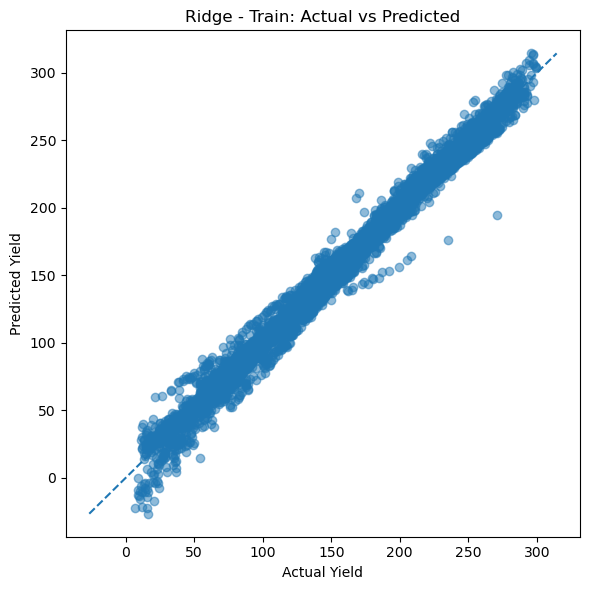

In [12]:
# Ridge: Actual vs Predicted (Train)
plt.figure(figsize=(6, 6))
plt.scatter(y_train, ridge_train_pred, alpha=0.5)
low = min(y_train.min(), ridge_train_pred.min())
high = max(y_train.max(), ridge_train_pred.max())
plt.plot([low, high], [low, high], "--")
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Ridge - Train: Actual vs Predicted")
plt.tight_layout()
plt.show()


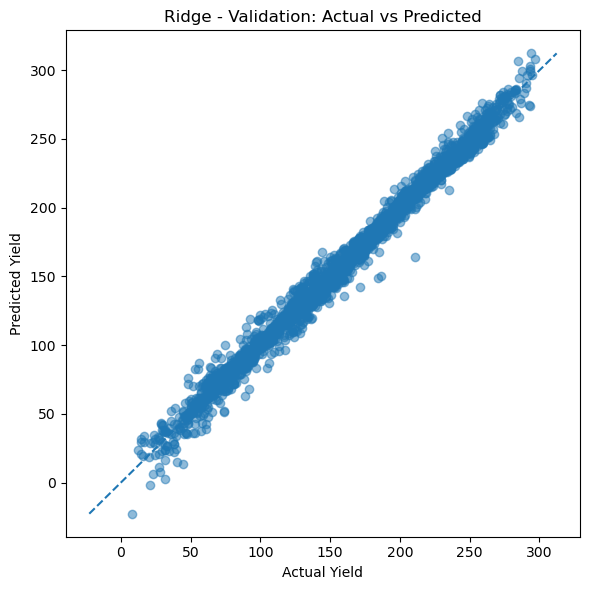

In [13]:
# Ridge: Actual vs Predicted (Validation)
plt.figure(figsize=(6, 6))
plt.scatter(y_val, ridge_val_pred, alpha=0.5)
low = min(y_val.min(), ridge_val_pred.min())
high = max(y_val.max(), ridge_val_pred.max())
plt.plot([low, high], [low, high], "--")
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Ridge - Validation: Actual vs Predicted")
plt.tight_layout()
plt.show()


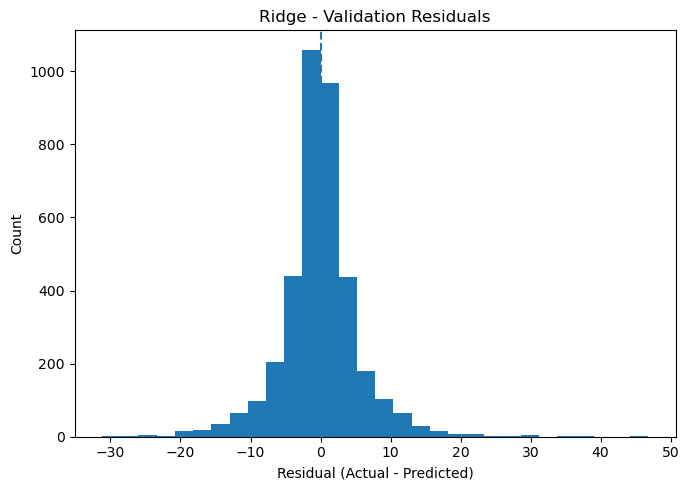

In [14]:
# Ridge: Residual histogram (Validation)
ridge_residuals = y_val - ridge_val_pred

plt.figure(figsize=(7, 5))
plt.hist(ridge_residuals, bins=30)
plt.axvline(0, linestyle="--")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Count")
plt.title("Ridge - Validation Residuals")
plt.tight_layout()
plt.show()


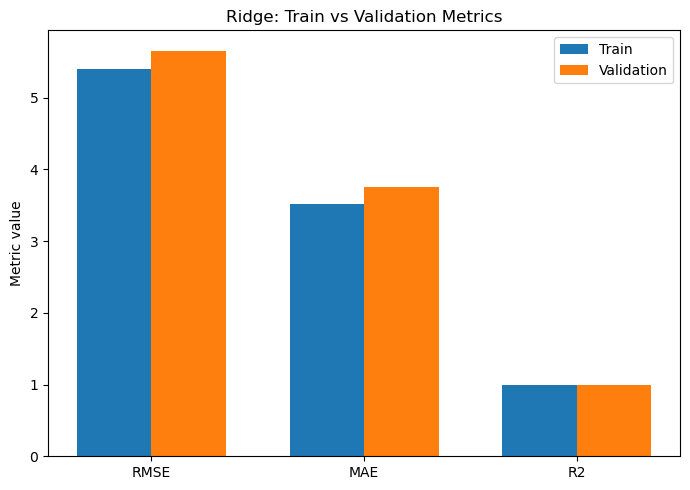

In [15]:
# Ridge: Train vs Validation metrics plot
ridge_metric_names = ["RMSE", "MAE", "R2"]
ridge_train_values = [ridge_train_rmse, ridge_train_mae, ridge_train_r2]
ridge_val_values = [ridge_val_rmse, ridge_val_mae, ridge_val_r2]

x = np.arange(len(ridge_metric_names))
width = 0.35

plt.figure(figsize=(7, 5))
plt.bar(x - width/2, ridge_train_values, width, label="Train")
plt.bar(x + width/2, ridge_val_values, width, label="Validation")
plt.xticks(x, ridge_metric_names)
plt.ylabel("Metric value")
plt.title("Ridge: Train vs Validation Metrics")
plt.legend()
plt.tight_layout()
plt.show()


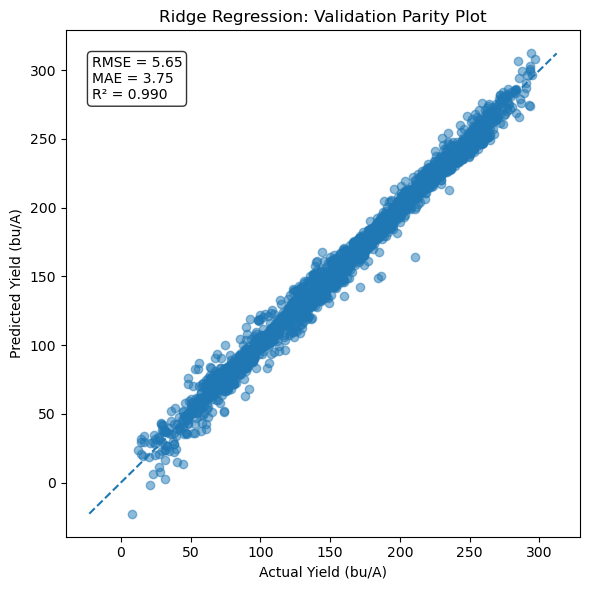

In [28]:
# Ridge - Validation parity plot
plt.figure(figsize=(6, 6))
plt.scatter(y_val, ridge_val_pred, alpha=0.5)

low = min(y_val.min(), ridge_val_pred.min())
high = max(y_val.max(), ridge_val_pred.max())
plt.plot([low, high], [low, high], linestyle="--")

plt.xlabel("Actual Yield (bu/A)")
plt.ylabel("Predicted Yield (bu/A)")
plt.title("Ridge Regression: Validation Parity Plot")

plt.text(
    0.05, 0.95,
    f"RMSE = {ridge_val_rmse:.2f}\nMAE = {ridge_val_mae:.2f}\nR² = {ridge_val_r2:.3f}",
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.tight_layout()
plt.savefig("ridge_validation_parity.png", bbox_inches="tight")
plt.show()

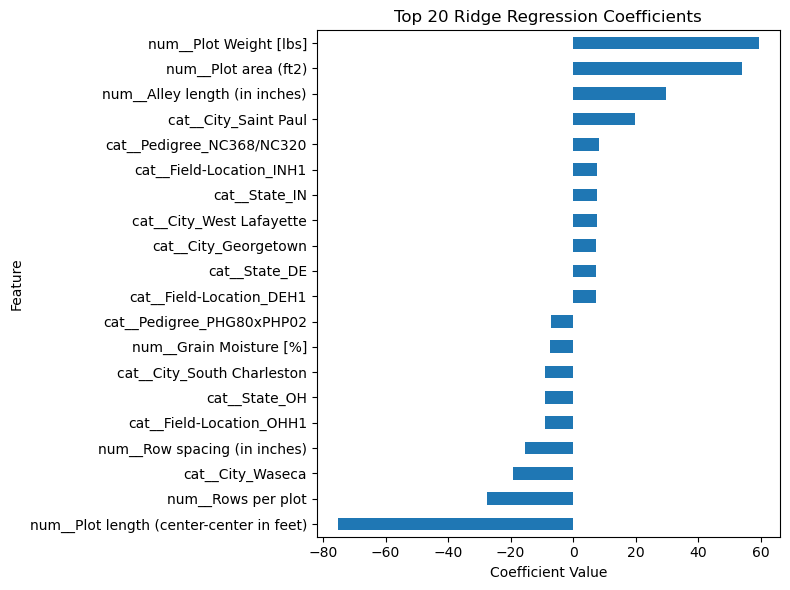

In [32]:
# Ridge coefficients
ridge_model = ridge_best.named_steps["model"]
ridge_preprocessor_fitted = ridge_best.named_steps["preprocessor"]

feature_names_ridge = ridge_preprocessor_fitted.get_feature_names_out()
ridge_coefs = pd.Series(ridge_model.coef_, index=feature_names_ridge)

top_ridge_features = ridge_coefs.abs().sort_values(ascending=False).head(20).index
top_ridge_coefs = ridge_coefs.loc[top_ridge_features].sort_values()

plt.figure(figsize=(8, 6))
top_ridge_coefs.plot(kind="barh")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Top 20 Ridge Regression Coefficients")
plt.tight_layout()
plt.savefig("ridge_top_coefficients.png", bbox_inches="tight")
plt.show()

In [16]:
# Random Forest pipeline
rf_pipeline = Pipeline(steps=[
    ("preprocessor", rf_preprocessor),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

# Random Forest hyperparameter grid
rf_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

# Random Forest GridSearch
rf_grid = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest parameters:", rf_grid.best_params_)
print("Best Random Forest CV RMSE:", -rf_grid.best_score_)


Best Random Forest parameters: {'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best Random Forest CV RMSE: 2.475898843113787


In [17]:
# Best Random Forest model predictions
rf_best = rf_grid.best_estimator_

rf_train_pred = rf_best.predict(X_train)
rf_val_pred = rf_best.predict(X_val)

# Random Forest train metrics
rf_train_rmse = np.sqrt(mean_squared_error(y_train, rf_train_pred))
rf_train_mae = mean_absolute_error(y_train, rf_train_pred)
rf_train_r2 = r2_score(y_train, rf_train_pred)

# Random Forest validation metrics
rf_val_rmse = np.sqrt(mean_squared_error(y_val, rf_val_pred))
rf_val_mae = mean_absolute_error(y_val, rf_val_pred)
rf_val_r2 = r2_score(y_val, rf_val_pred)

rf_metrics_table = pd.DataFrame({
    "Dataset": ["Train", "Validation"],
    "RMSE": [rf_train_rmse, rf_val_rmse],
    "MAE": [rf_train_mae, rf_val_mae],
    "R2": [rf_train_r2, rf_val_r2]
})

print("Random Forest results:")
display(rf_metrics_table)


Random Forest results:


,Dataset,RMSE,MAE,R2
0,Train,0.764773,0.329079,0.999810
1,Validation,1.522186,0.831632,0.999261


In [18]:
# Random Forest validation predictions table
rf_predictions_val = pd.DataFrame({
    "Actual": y_val.values,
    "Predicted": rf_val_pred,
    "Residual": y_val.values - rf_val_pred
})

rf_predictions_val.head(10)


,Actual,Predicted,Residual
0,119.477265,120.020267,-0.543002
1,178.350768,178.238142,0.112626
2,203.443979,204.176371,-0.732392
3,91.889574,94.397033,-2.507459
4,125.504350,128.192555,-2.688205
5,170.512100,170.455048,0.057052
6,170.287738,170.018796,0.268943
7,187.510519,187.299538,0.210981
8,124.009628,125.350800,-1.341172
9,70.669391,74.014487,-3.345097


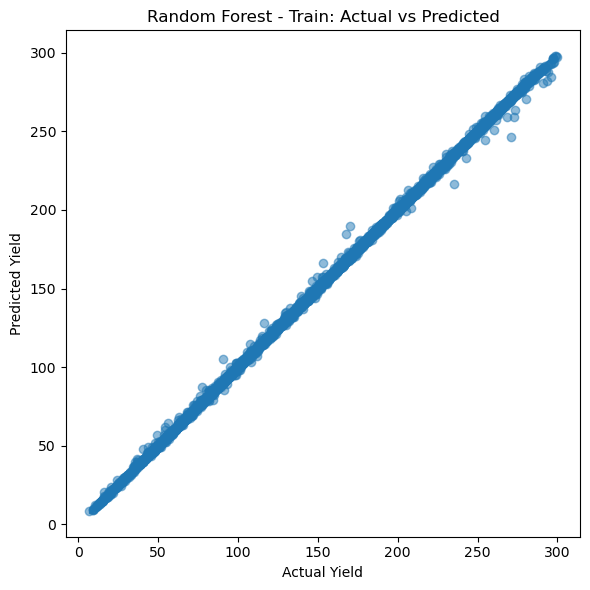

In [19]:
# Random Forest: Actual vs Predicted (Train)
plt.figure(figsize=(6, 6))
plt.scatter(y_train, rf_train_pred, alpha=0.5)
low = min(y_train.min(), rf_train_pred.min())
high = max(y_train.max(), rf_train_pred.max())
plt.plot([low, high], [low, high], "--")
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Random Forest - Train: Actual vs Predicted")
plt.tight_layout()
plt.show()


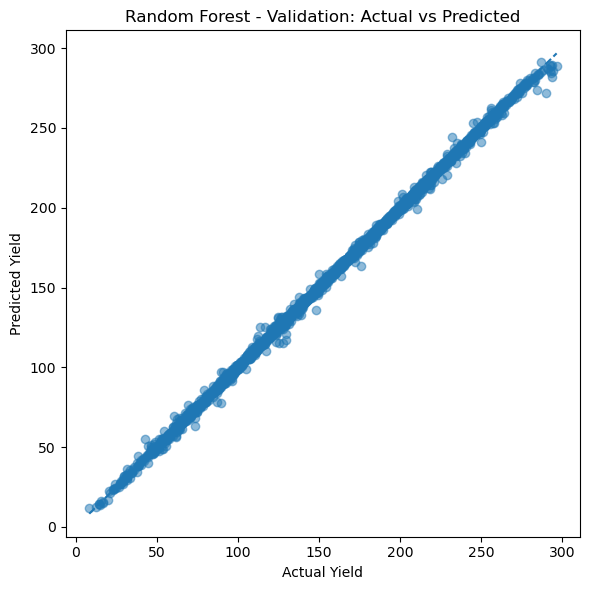

In [20]:
# Random Forest: Actual vs Predicted (Validation)
plt.figure(figsize=(6, 6))
plt.scatter(y_val, rf_val_pred, alpha=0.5)
low = min(y_val.min(), rf_val_pred.min())
high = max(y_val.max(), rf_val_pred.max())
plt.plot([low, high], [low, high], "--")
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Random Forest - Validation: Actual vs Predicted")
plt.tight_layout()
plt.show()


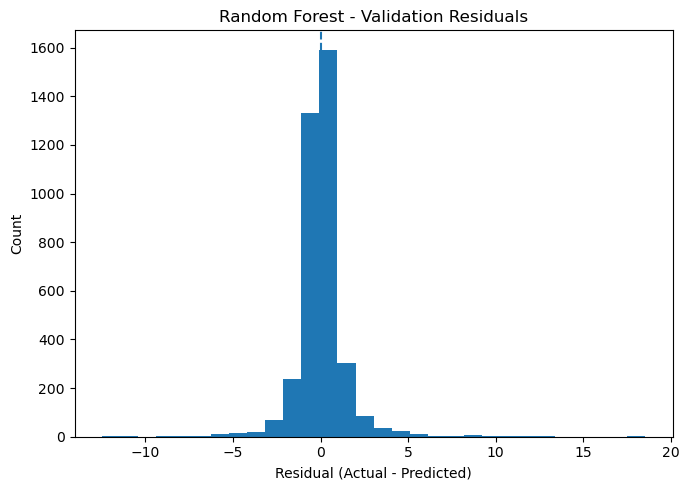

In [21]:
# Random Forest: Residual histogram (Validation)
rf_residuals = y_val - rf_val_pred

plt.figure(figsize=(7, 5))
plt.hist(rf_residuals, bins=30)
plt.axvline(0, linestyle="--")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Count")
plt.title("Random Forest - Validation Residuals")
plt.tight_layout()
plt.show()


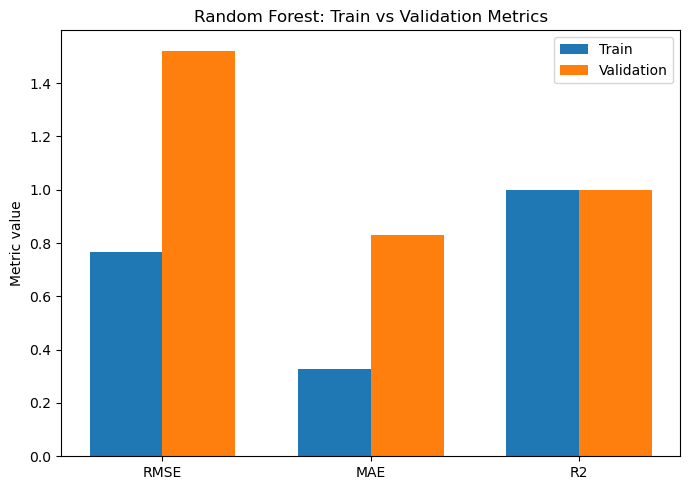

In [22]:
# Random Forest: Train vs Validation metrics plot
rf_metric_names = ["RMSE", "MAE", "R2"]
rf_train_values = [rf_train_rmse, rf_train_mae, rf_train_r2]
rf_val_values = [rf_val_rmse, rf_val_mae, rf_val_r2]

x = np.arange(len(rf_metric_names))
width = 0.35

plt.figure(figsize=(7, 5))
plt.bar(x - width/2, rf_train_values, width, label="Train")
plt.bar(x + width/2, rf_val_values, width, label="Validation")
plt.xticks(x, rf_metric_names)
plt.ylabel("Metric value")
plt.title("Random Forest: Train vs Validation Metrics")
plt.legend()
plt.tight_layout()
plt.show()


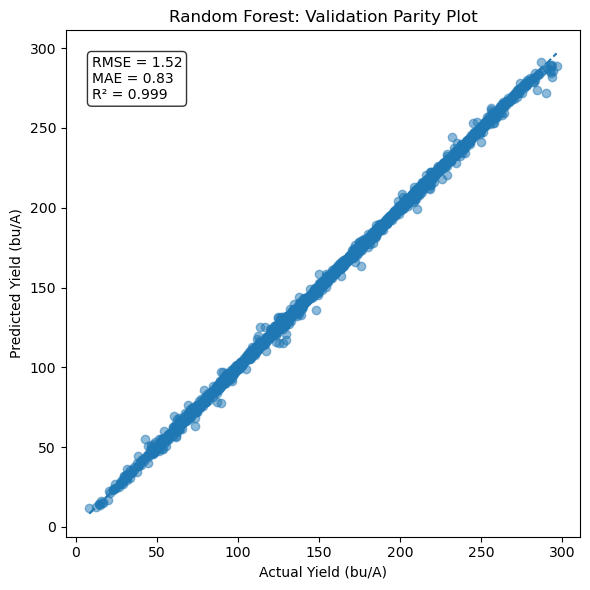

In [29]:
# Random Forest - Validation parity plot
plt.figure(figsize=(6, 6))
plt.scatter(y_val, rf_val_pred, alpha=0.5)

low = min(y_val.min(), rf_val_pred.min())
high = max(y_val.max(), rf_val_pred.max())
plt.plot([low, high], [low, high], linestyle="--")

plt.xlabel("Actual Yield (bu/A)")
plt.ylabel("Predicted Yield (bu/A)")
plt.title("Random Forest: Validation Parity Plot")

plt.text(
    0.05, 0.95,
    f"RMSE = {rf_val_rmse:.2f}\nMAE = {rf_val_mae:.2f}\nR² = {rf_val_r2:.3f}",
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.tight_layout()
plt.savefig("rf_validation_parity.png", bbox_inches="tight")
plt.show()

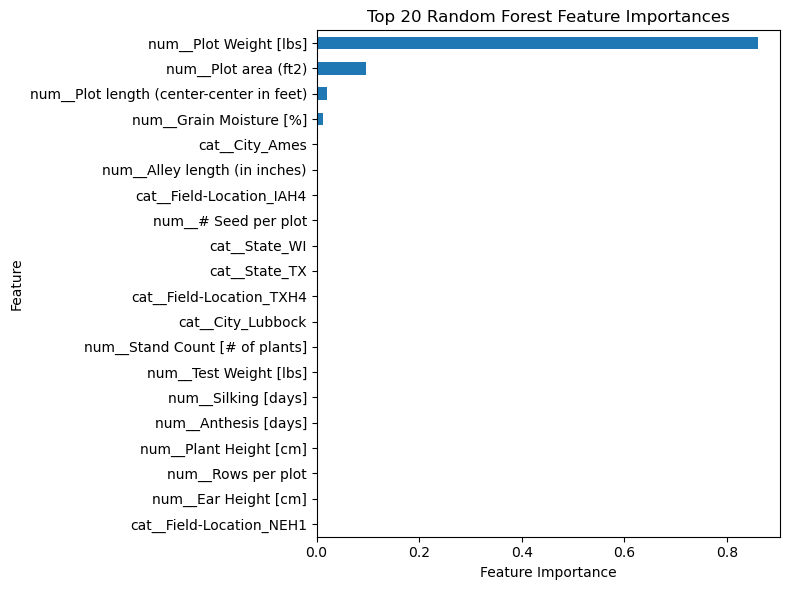

In [31]:
# Random Forest feature importance
rf_model = rf_best.named_steps["model"]
rf_preprocessor_fitted = rf_best.named_steps["preprocessor"]

feature_names_rf = rf_preprocessor_fitted.get_feature_names_out()
rf_importances = pd.Series(rf_model.feature_importances_, index=feature_names_rf)

top_rf = rf_importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(8, 6))
top_rf.sort_values().plot(kind="barh")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 20 Random Forest Feature Importances")
plt.tight_layout()
plt.savefig("rf_feature_importance.png", bbox_inches="tight")
plt.show()

In [23]:
# Final comparison table
comparison_table = pd.DataFrame({
    "Model": ["Ridge", "Ridge", "Random Forest", "Random Forest"],
    "Dataset": ["Train", "Validation", "Train", "Validation"],
    "RMSE": [ridge_train_rmse, ridge_val_rmse, rf_train_rmse, rf_val_rmse],
    "MAE": [ridge_train_mae, ridge_val_mae, rf_train_mae, rf_val_mae],
    "R2": [ridge_train_r2, ridge_val_r2, rf_train_r2, rf_val_r2]
})

comparison_table


,Model,Dataset,RMSE,MAE,R2
0,Ridge,Train,5.402608,3.522156,0.990539
1,Ridge,Validation,5.653890,3.750153,0.989799
2,Random Forest,Train,0.764773,0.329079,0.999810
3,Random Forest,Validation,1.522186,0.831632,0.999261


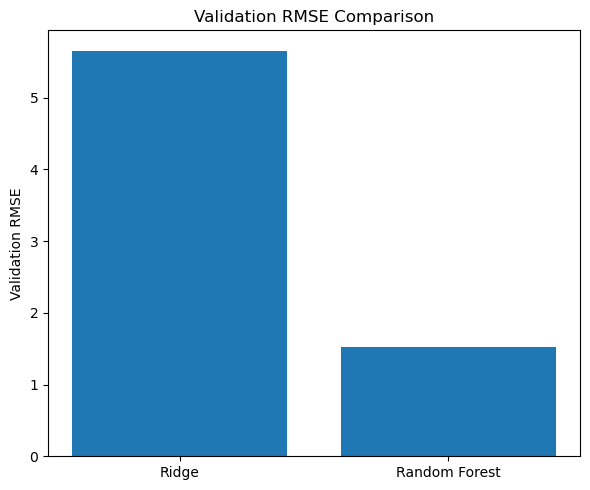

In [24]:
# Validation RMSE comparison
val_only = comparison_table[comparison_table["Dataset"] == "Validation"]

plt.figure(figsize=(6, 5))
plt.bar(val_only["Model"], val_only["RMSE"])
plt.ylabel("Validation RMSE")
plt.title("Validation RMSE Comparison")
plt.tight_layout()
plt.show()


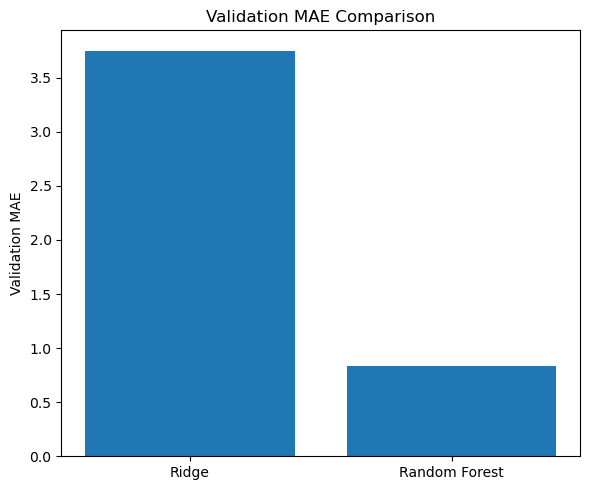

In [25]:
# Validation MAE comparison
plt.figure(figsize=(6, 5))
plt.bar(val_only["Model"], val_only["MAE"])
plt.ylabel("Validation MAE")
plt.title("Validation MAE Comparison")
plt.tight_layout()
plt.show()


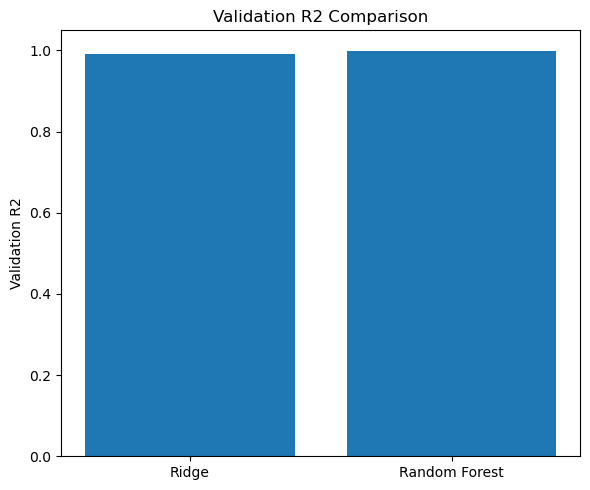

In [26]:
# Validation R2 comparison
plt.figure(figsize=(6, 5))
plt.bar(val_only["Model"], val_only["R2"])
plt.ylabel("Validation R2")
plt.title("Validation R2 Comparison")
plt.tight_layout()
plt.show()


In [27]:
# Save result tables
ridge_metrics_table.to_csv("ridge_metrics_table.csv", index=False)
rf_metrics_table.to_csv("random_forest_metrics_table.csv", index=False)
comparison_table.to_csv("ridge_vs_random_forest_comparison.csv", index=False)

print("Saved: ridge_metrics_table.csv")
print("Saved: random_forest_metrics_table.csv")
print("Saved: ridge_vs_random_forest_comparison.csv")


Saved: ridge_metrics_table.csv
Saved: random_forest_metrics_table.csv
Saved: ridge_vs_random_forest_comparison.csv


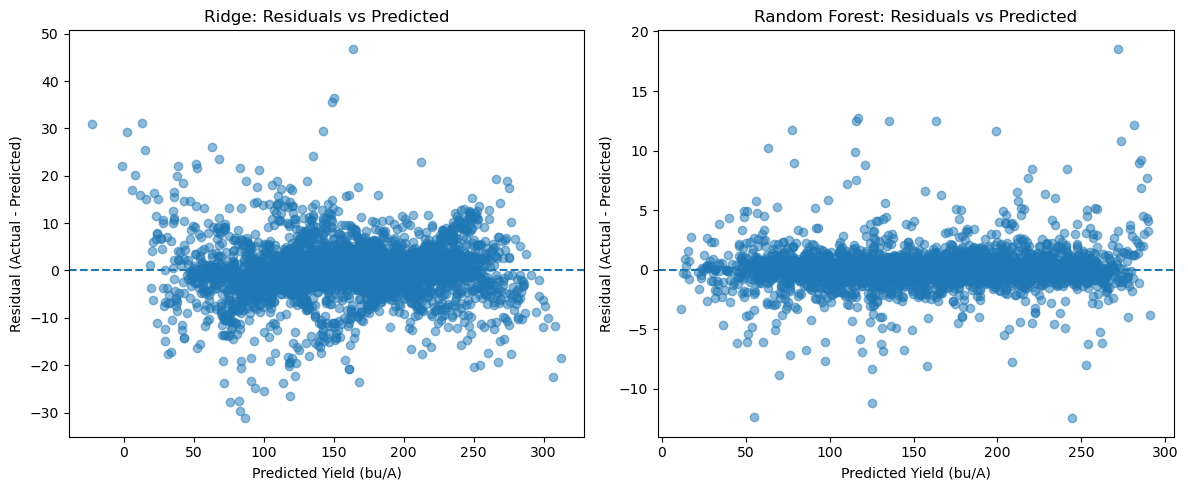

In [30]:
# Residuals
ridge_residuals = y_val - ridge_val_pred
rf_residuals = y_val - rf_val_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(ridge_val_pred, ridge_residuals, alpha=0.5)
axes[0].axhline(0, linestyle="--")
axes[0].set_xlabel("Predicted Yield (bu/A)")
axes[0].set_ylabel("Residual (Actual - Predicted)")
axes[0].set_title("Ridge: Residuals vs Predicted")

axes[1].scatter(rf_val_pred, rf_residuals, alpha=0.5)
axes[1].axhline(0, linestyle="--")
axes[1].set_xlabel("Predicted Yield (bu/A)")
axes[1].set_ylabel("Residual (Actual - Predicted)")
axes[1].set_title("Random Forest: Residuals vs Predicted")

plt.tight_layout()
plt.savefig("residuals_vs_predicted.png", bbox_inches="tight")
plt.show()